## Restaurant review argument mining
This notebook takes in a dataset called "Resaurant reviews, dataset for Natural language processing by Arsh Anwar on Kaggle"


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.linear_model import SGDClassifier

import seaborn as sns


df = pd.read_csv('restaurant_reviews.tsv', sep='\t')

df.describe()

[nltk_data] Downloading package punkt to C:\Users\Leo
[nltk_data]     H\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Liked
count,1000.00000
mean,0.50000
std,0.50025
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [2]:
empty_reviews = df.isnull().sum()
print(empty_reviews)

Review    0
Liked     0
dtype: int64


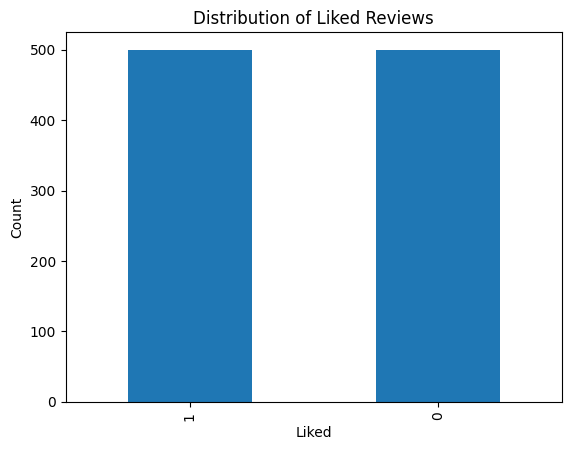

In [3]:
liked = df['Liked'].value_counts()

liked.plot(kind='bar')
plt.xlabel('Liked')
plt.ylabel('Count')
plt.title('Distribution of Liked Reviews')
plt.show()

In [4]:
tokenized_reviews = df['Review'].apply(word_tokenize)
x = tokenized_reviews.apply(lambda tokens: ' '.join(tokens))
y = df['Liked']

train_X, test_X, train_Y, test_Y = train_test_split(x, y, test_size=0.2, random_state=42)

print(train_X.shape)
print(test_Y.shape)



(800,)
(200,)


I used NLTK to encode the data into tokens. I originally removed the stop words but i want getting around 80% accuracy. I then included the stopwords and got 84.6%

- different fine tuning tested
    - ngram(1,2), maxdf=0.9, mindf=5 -> 0.686
    - ngram(1,2), maxdf=0.9, mindf=2 -> 0.762
    - ngram(1,3), maxdf=0.9, mindf=2 -> 0.762
    - ngram(2,3), maxdf=0.9, mindf=2 -> 0.560
    - ngram(3,3), maxdf=0.9, mindf=2 -> 0.5
    - ngram(1,3), maxdf=0.9, mindf=1 -> 0.806
    - ngram(1,3), maxdf=0.75, mindf=1 -> 0.806
    - ngram(1,3), maxdf=1, mindf=1 -> 0.613
    - ngram(1,3), maxdf=0.8, mindf=1 -> 0.806
    - ngram(1,3), maxdf=0.8, mindf=1, sublinear=true -> 0.810
    - ngram(1,3), maxdf=0.8, mindf=1, sublinear=false -> 0.806
    - ngram(1,3), maxdf=0.8, mindf=1, sublinear=false - using tokenized_reviews with stop words ->0.846 SGDClassifier

In [5]:

def train_model(train_X, train_Y, test_X, test_Y):
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,3),max_df=0.8,min_df=1, sublinear_tf=True)),
        ("clf", SGDClassifier(loss='log_loss', random_state=42)),
    ])

    model.fit(train_X, train_Y)
    prediction = model.predict(test_X)
    acc = balanced_accuracy_score(y_true=test_Y, y_pred=prediction)
    print("Accuracy:", acc)
    
    return model, prediction

model, prediction = train_model(train_X, train_Y, test_X, test_Y)
print(prediction)

Accuracy: 0.8465544871794872
[1 1 1 1 1 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 1
 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0
 1 0 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1
 1 0 0 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 0 1 1 0 0 0 0
 1 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 0 1 0 0
 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1]


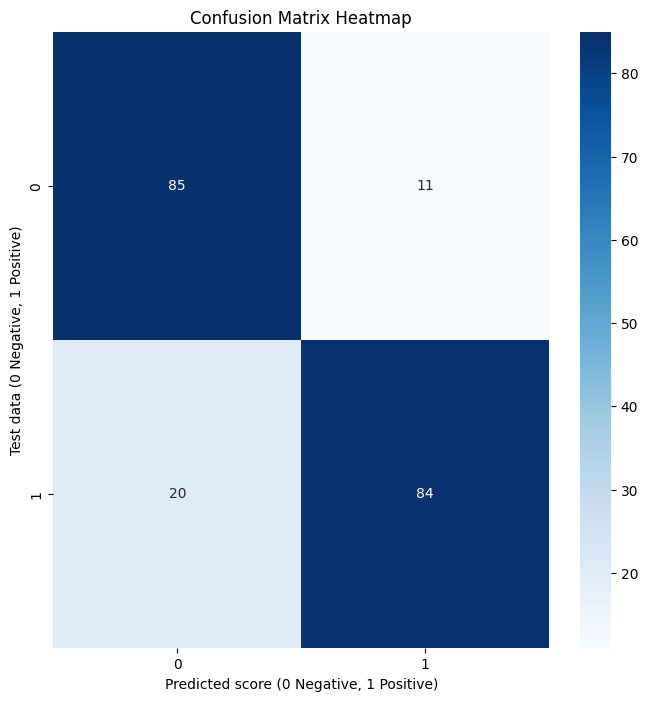

In [6]:
matrix = confusion_matrix(test_Y, prediction)

plt.figure(figsize=(8, 8))


sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(len(matrix)),
            yticklabels=range(len(matrix)))


plt.xlabel('Predicted score (0 Negative, 1 Positive)')
plt.ylabel('Test data (0 Negative, 1 Positive)')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Reflection
Used many different models wwith various different settings and couldnt get higher than 84.6% accuracy. Could be due to the dataset size as it only had 1000 lines and therefore only 800 to train off. Also I could utalise transformers for a better output but due to my research it seems they are more effective on larger datasets. 